# Notebook 1: Data Exploration

Dataset: freMTPL2 (French Motor TPL) — 678,013 policies, 26,639 claims

Goal: understand the loss distribution and identify heavy tail behavior.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import load_fremtpl2_data, create_loss_portfolio, add_catastrophe_events, save_portfolio

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load Data

In [2]:
df_freq, df_sev = load_fremtpl2_data()
print(f'Frequency data: {df_freq.shape}')
print(f'Severity data:  {df_sev.shape}')
df_sev.head()

Loading from local cache...
Frequency data: (678013, 12)
Severity data:  (26639, 2)
Frequency data: (678013, 12)
Severity data:  (26639, 2)


,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00


## 2. Descriptive Statistics

In [3]:
severity_col = 'ClaimAmount' if 'ClaimAmount' in df_sev.columns else df_sev.columns[-1]

print('Severity Statistics:')
print(df_sev[severity_col].describe())

print('\nPercentiles:')
for p in [50, 75, 90, 95, 99, 99.5, 99.9]:
    print(f'  P{p:5.1f}: {np.percentile(df_sev[severity_col], p):>12,.2f}')

Severity Statistics:
count    2.663900e+04
mean     2.278536e+03
std      2.929748e+04
min      1.000000e+00
25%      6.868100e+02
50%      1.172000e+03
75%      1.228080e+03
max      4.075401e+06
Name: ClaimAmount, dtype: float64

Percentiles:
  P 50.0:     1,172.00
  P 75.0:     1,228.08
  P 90.0:     2,799.07
  P 95.0:     4,861.68
  P 99.0:    16,793.70
  P 99.5:    34,386.99
  P 99.9:   162,784.44


## 3. Create Simulated Portfolio

In [4]:
losses = create_loss_portfolio(df_sev, n_simulations=50000)
losses_with_cat = add_catastrophe_events(losses, n_cat_events=10, cat_multiplier=100)

print(f'Portfolio size:  {len(losses_with_cat):,}')
print(f'Mean loss:       {losses_with_cat.mean():>12,.2f}')
print(f'Max loss:        {losses_with_cat.max():>12,.2f}')

Generated 50,000 simulated losses
Mean:      2,359.81
P99:      18,753.60
Max:   4,075,400.56
Added 10 catastrophe events (x100)
New max loss: 4,075,400.56
Portfolio size:  50,000
Mean loss:           2,372.57
Max loss:        4,075,400.56


## 4. Severity Distribution

Using P99 as x-axis limit to show meaningful distribution shape (max is 4M due to cat events).

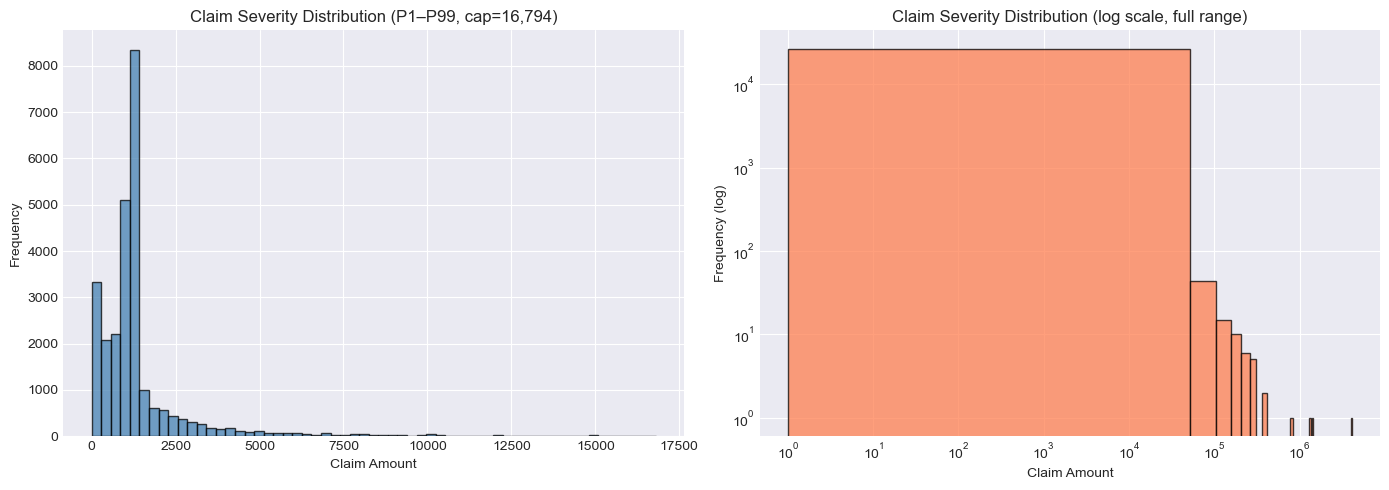

In [5]:
# Use P99 as xlim to avoid blank charts caused by extreme outliers
p99_sev = np.percentile(df_sev[severity_col], 99)
p99_losses = np.percentile(losses, 99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins_sev = np.linspace(0, p99_sev, 60)
axes[0].hist(df_sev[severity_col][df_sev[severity_col] <= p99_sev],
             bins=bins_sev, edgecolor='black', alpha=0.75, color='steelblue')
axes[0].set_xlabel('Claim Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Claim Severity Distribution (P1–P99, cap={p99_sev:,.0f})')

bins_log = np.linspace(1, df_sev[severity_col].max(), 80)
axes[1].hist(df_sev[severity_col], bins=bins_log, edgecolor='black', alpha=0.75, color='coral')
axes[1].set_xlabel('Claim Amount')
axes[1].set_ylabel('Frequency (log)')
axes[1].set_title('Claim Severity Distribution (log scale, full range)')
axes[1].set_yscale('log')
axes[1].set_xscale('log')

plt.tight_layout()
plt.savefig('../results/figures/01_severity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Loss Exceedance Curve

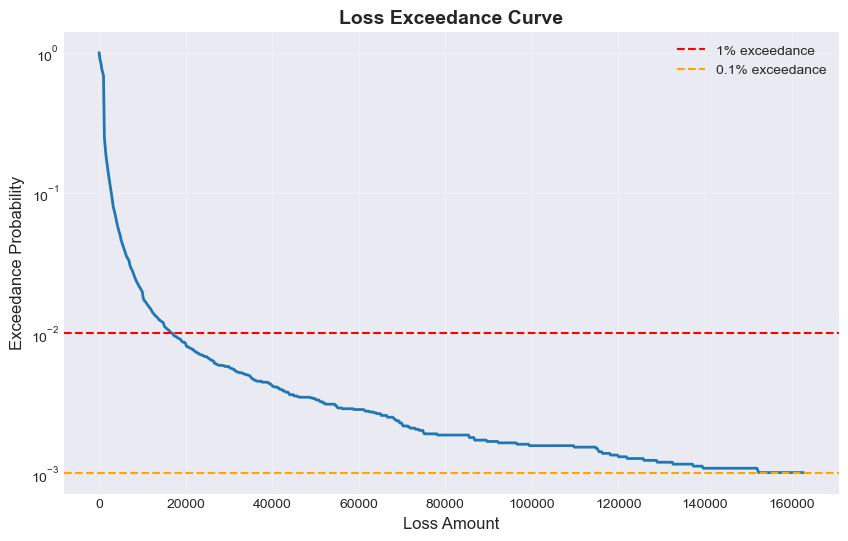

In [6]:
def exceedance_curve(data, thresholds):
    return np.array([np.mean(data > t) for t in thresholds])

p999 = np.percentile(df_sev[severity_col], 99.9)
thresholds = np.linspace(0, p999, 800)
exc_prob = exceedance_curve(df_sev[severity_col].values, thresholds)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, exc_prob, linewidth=2)
ax.set_xlabel('Loss Amount', fontsize=12)
ax.set_ylabel('Exceedance Probability', fontsize=12)
ax.set_title('Loss Exceedance Curve', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.axhline(y=0.01,  color='red',    linestyle='--', label='1% exceedance')
ax.axhline(y=0.001, color='orange', linestyle='--', label='0.1% exceedance')
ax.legend()

plt.savefig('../results/figures/02_exceedance_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Q-Q Plot — Evidence of Heavy Tail

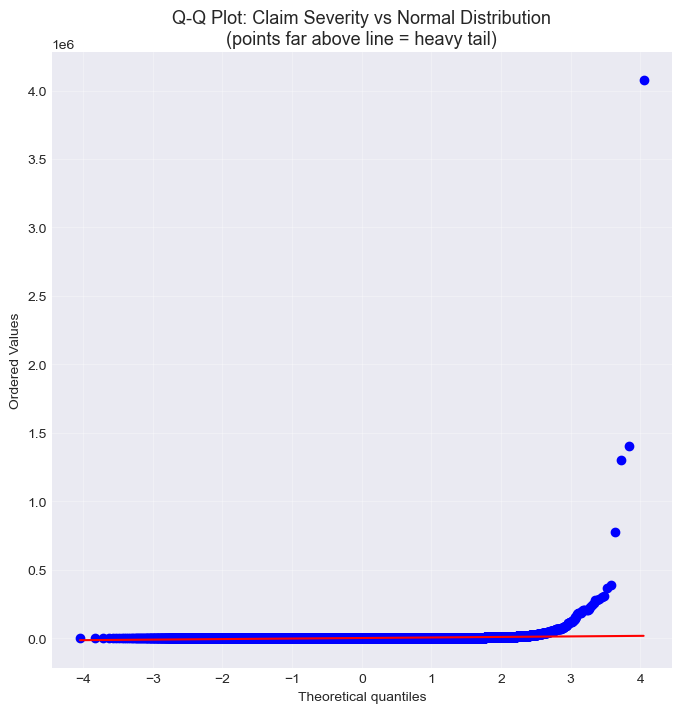

In [7]:
from scipy import stats

fig, ax = plt.subplots(figsize=(8, 8))
stats.probplot(df_sev[severity_col], dist='norm', plot=ax)
ax.set_title('Q-Q Plot: Claim Severity vs Normal Distribution\n(points far above line = heavy tail)', fontsize=13)
ax.grid(True, alpha=0.3)

plt.savefig('../results/figures/03_qq_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Simulated Portfolio: With and Without Catastrophes

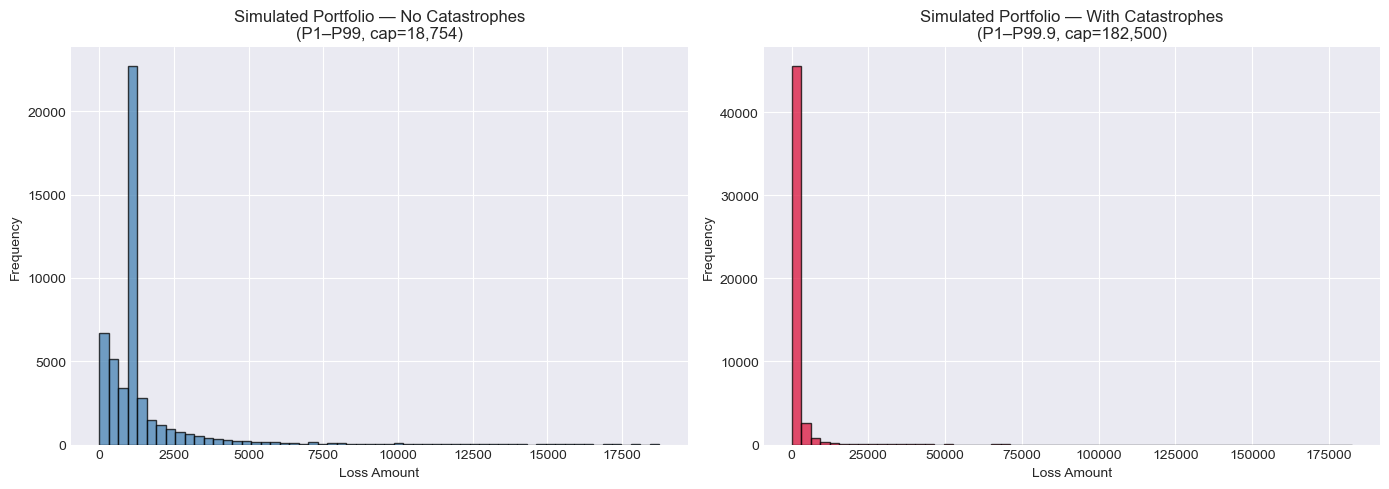

In [8]:
p99_port    = np.percentile(losses, 99)
p999_cat    = np.percentile(losses_with_cat, 99.9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins_base = np.linspace(0, p99_port, 60)
axes[0].hist(losses[losses <= p99_port], bins=bins_base,
             edgecolor='black', alpha=0.75, color='steelblue')
axes[0].set_xlabel('Loss Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Simulated Portfolio — No Catastrophes\n(P1–P99, cap={p99_port:,.0f})')

bins_cat = np.linspace(0, p999_cat, 60)
axes[1].hist(losses_with_cat[losses_with_cat <= p999_cat], bins=bins_cat,
             edgecolor='black', alpha=0.75, color='crimson')
axes[1].set_xlabel('Loss Amount')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Simulated Portfolio — With Catastrophes\n(P1–P99.9, cap={p999_cat:,.0f})')

plt.tight_layout()
plt.savefig('../results/figures/04_portfolio_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Save Portfolio

In [9]:
save_portfolio(losses_with_cat)
print('Portfolio saved.')

Portfolio saved: ../data/processed/claims_cleaned.csv  (50,000 rows)
Portfolio saved.


## 9. Summary

In [10]:
print('=' * 60)
print('PORTFOLIO SUMMARY')
print('=' * 60)
for label, val in [
    ('Total claims',  f'{len(losses_with_cat):,}'),
    ('Mean loss',     f'{losses_with_cat.mean():>15,.2f}'),
    ('Median loss',   f'{np.median(losses_with_cat):>15,.2f}'),
    ('Std dev',       f'{losses_with_cat.std():>15,.2f}'),
    ('VaR 95%',       f'{np.percentile(losses_with_cat, 95):>15,.2f}'),
    ('VaR 99%',       f'{np.percentile(losses_with_cat, 99):>15,.2f}'),
    ('VaR 99.5%',     f'{np.percentile(losses_with_cat, 99.5):>15,.2f}'),
    ('Max loss',      f'{losses_with_cat.max():>15,.2f}'),
]:
    print(f'  {label:<20} {val}')
print('=' * 60)

PORTFOLIO SUMMARY
  Total claims         50,000
  Mean loss                   2,372.57
  Median loss                 1,172.00
  Std dev                    26,983.42
  VaR 95%                     4,925.36
  VaR 99%                    18,825.38
  VaR 99.5%                  39,071.07
  Max loss                4,075,400.56
